# P2: Exploratory sequence analysis

This is exploratory sequence analysis with no labels: the no-label first look you reach for *before* you have groups to compare. It sits early in the catalog, right after the CPP signature, before any test-vs-reference contrast exists. When you have sequences but no labels yet, you can still describe what your sequences actually look like before any comparison: the per-position amino-acid composition (a **sequence logo**) and the per-position conservation (information content, in *bits*). This is *not* **determinant discovery**, the test-vs-reference contrast that yields a **signature**. There is no contrast here at all: one pooled set, no test/reference split, no signature. We call this no-label first look *determinant-free profiling* as shorthand throughout (note: "profiling" is our informal label here, not a glossary term).

With no labels you cannot yet ask *what distinguishes my groups* (that is **determinant discovery**, see P1: CPP signature). But you *can* pool every sequence and ask two pre-questions: *where along the sequence does signal concentrate*, and *is there enough structure to make a comparison worth running*? A logo answers the first; conservation in bits answers the second.

A one-line decision rule: **Do you have labels? No, run exploratory profiling (this protocol). Yes, run CPP signature (P1).**

We work at the **domain level** (dataset prefix `DOM_`): the **unit of comparison** is the TMD-centric **part** set `jmd_n` / `tmd` / `jmd_c`, the native ground for CPP.

> **Key mental model.** A sequence logo is a pooled tally: letter height says *what* sits at each position, the gray bar says *how conserved* that position is. Conservation only means something against a baseline, because a finite set always looks a little conserved by chance, so compare your set against the same residues shuffled. And a pooled logo *describes* one set: only splitting it by a label turns it into a comparison.

**When to use it.** Use this protocol when you have a set of sequences (one biological family, one screen, one organism) and want a first look *before* committing to any model or comparison. Typical questions:

- *Is my TMD region more conserved than its flanking JMDs?*
- *Is any single position dominated by one or a few residues?*
- *Are my sequences even structured enough to be worth profiling?*

**When not to use it.** Once you have two **labelled** sets and want to know *what physicochemically separates them*, skip ahead to **determinant discovery** via **CPP** (P1: CPP signature). A logo describes the **composition** of one pooled set; it does *not* contrast a **test group** (`label=1`) against a **reference group** (`label=0`), and it produces no **signature**.

**Input.** The input is a `df_seq` in **position-based** format: an `entry` column (unique protein id), a `sequence` column, and the `tmd_start` / `tmd_stop` boundaries (**1-based, start- and stop-inclusive**).

There is no upstream protocol: this is the no-label first look, used before you have labels. Its input is whatever sequence table you bring; here we use a small bundled dataset. Note that a `label` column may be present (it is, in `DOM_GSEC`), but we **ignore it on purpose** (profiling is determinant-free).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import aaanalysis as aa

aa.options["verbose"] = False

# DOM_GSEC at the domain level; n=25 per class -> 50 rows. We will NOT use df_seq["label"] (until the group contrast).
# Every loader option by name; all but `name` and `n` sit at their default here.
df_seq = aa.load_dataset(
    name="DOM_GSEC", n=25,
    random=False,                 # True would draw a different n per class on every call
    non_canonical_aa="remove",    # "keep" or "gap" would let X / U / B through instead of dropping the entry
    min_len=None, max_len=None,   # a sequence-length window; None keeps every entry
    aa_window_size=9,             # only used by the residue-level AA_* datasets
    verbose=False,                # True reports how many entries each removal step dropped
)
aa.display_df(df=df_seq[["entry", "sequence", "tmd_start", "tmd_stop"]], n_rows=10, show_shape=True)

DataFrame shape: (50, 4)


,entry,sequence,tmd_start,tmd_stop
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,37,59
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,50,72
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,41,63
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,97,119
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,59,81
6,P01135,MVPSAGQLALFALGI...LLKGRTACCHSETVV,99,121
7,O43914,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,42,64
8,P05556,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,729,751
9,P16234,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,527,549
10,P50895,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,549,571


In [2]:
# Slice each sequence into the parts we profile.
# Request jmd_n, tmd, jmd_c so the logo spans the full JMD-N + TMD + JMD-C window.
sf = aa.SequenceFeature(verbose=False)   # verbose=True would print the part-building steps
df_parts = sf.get_df_parts(
    df_seq=df_seq,
    list_parts=["jmd_n", "tmd", "jmd_c"],
    all_parts=False,                  # True would build every possible part, not just the three requested
    jmd_n_len=10,
    jmd_c_len=10,
    tmd_len=None,                     # only used for the anchor-based df_seq format (sequence + pos)
    remove_entries_with_gaps=False,   # True would drop entries whose parts do not fully fit the sequence
    replace_non_canonical_aa=False,   # True would replace X / U / B by the gap symbol "-"
)
aa.display_df(df=df_parts, n_rows=10, show_shape=True)

DataFrame shape: (50, 3)


,jmd_n,tmd,jmd_c
entry,,,
Q14802,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
Q86UE4,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
Q969W9,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
P53801,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
Q8IUW5,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE
P01135,AVVAASQKKQ,AITALVVVSIVALAVLIITCVLI,HCCQVRKHCE
O43914,DCSCSTVSPG,VLAGIVMGDLVLTVLIALAVYFL,GRLVPRGRGA
P05556,ENPECPTGPD,IIPIVAGVVAGIVLIGLALLLIW,KLLMIIHDRR
P16234,VAPTLRSELT,VAAAVLVLLVIVIISLIVLVVIW,KQKPRYEIRW


**Run.** Behind the scenes, `AALogo` aligns the variable-length TMDs to a fixed width (`tmd_len`) and tallies the per-position composition across **all** sequences (see the AALogo examples for the function details). We pass `labels=None`, so every sequence is pooled into a single profile: this is what makes the read-out determinant-free.

Two quantities come out:

- `get_df_logo`: a **composition** matrix (`probability` per amino acid, per position).
- `get_df_logo_info`: per-position **conservation** in bits (0 = uniform, ~4.32 = a single fully-conserved residue), which `get_conservation` collapses to a scalar (`min`, `mean`, `median` or `max` over positions).

Profiling is fully deterministic (every step is a pooled tally), so no `random_state` is needed here.

In [3]:
aal = aa.AALogo(logo_type="probability")

# Deterministic: pooled tally over all sequences, no RNG -> random_state not applicable.
# tmd_len=20 aligns the TMDs to a fixed width counted from their N-terminus (start_n=True):
# 10 (jmd_n) + 20 (tmd) + 10 (jmd_c) = 40 positions.
df_logo = aal.get_df_logo(
    df_parts=df_parts,
    labels=None, label_test=1,         # no labels: one pooled profile (label_test is then unused)
    tmd_len=20, start_n=True,          # TMD alignment width and direction
    characters_to_ignore=".-",         # gap symbols are not counted as residues
    pseudocount=0.0,                   # raw frequencies, no smoothing
)
df_logo_info = aal.get_df_logo_info(
    df_parts=df_parts, labels=None, label_test=1, tmd_len=20, start_n=True,
    characters_to_ignore=".-", pseudocount=0.0,
)

# get_conservation collapses the per-position bits into one number, four ways.
df_cons = pd.DataFrame(
    {value_type: [aal.get_conservation(df_logo_info=df_logo_info, value_type=value_type)]
     for value_type in ["min", "mean", "median", "max"]},
    index=["bits (pooled set)"],
).round(2)
aa.display_df(df=df_cons, n_rows=10, show_shape=True)

DataFrame shape: (1, 4)


,min,mean,median,max
bits (pooled set),0.240000,1.010000,1.070000,1.790000


**Output.** Three things flow out: the logo matrix `df_logo`, the per-position conservation series `df_logo_info`, and the conservation summaries above. The figure below is the single pooled logo: **letter height = composition** at that position, and the **gray overlay bar = conservation in bits**. Tall, single-letter stacks mark dominated positions; tall gray bars mark conserved ones.

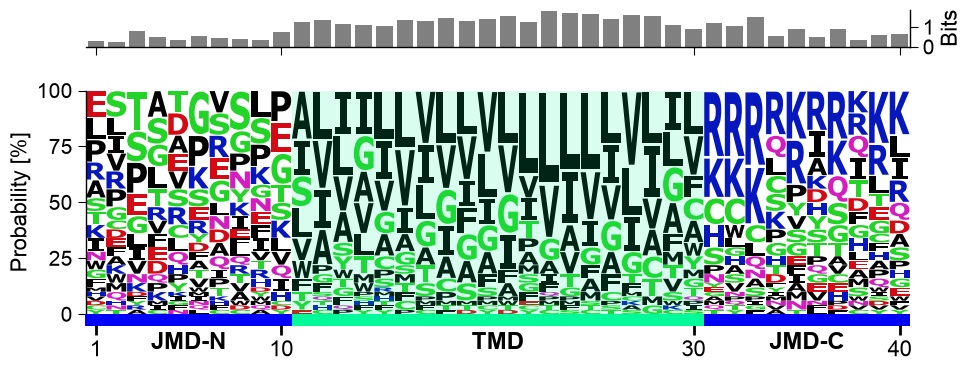

In [4]:
# Publication styling (plotting_prelude): clean fonts, no bold weight.
aa.plot_settings(font_scale=0.9, weight_bold=False)

aal_plot = aa.AALogoPlot(logo_type="probability", jmd_n_len=10, jmd_c_len=10, verbose=False)
fig, ax = aal_plot.single_logo(
    df_logo=df_logo,
    df_logo_info=df_logo_info,
    figsize=(10, 4),
    fontsize_tmd_jmd=aa.plot_gcfs() + 1,   # legible JMD-N / TMD / JMD-C part labels
    weight_tmd_jmd="bold",
)
plt.tight_layout()
plt.show()

**What the logo makes visible.** The figure above packs two readings into one picture, and it is easy to take either on faith. The next figures pull them apart, each against its alternative: *composition vs conservation* (the same set drawn in bits), *signal vs chance* (the real set vs a shuffled baseline), and *one set vs two groups* (the pooled logo vs a split by label).

**Composition vs conservation.** In the probability logo every stack has height 1, so a variable position and a conserved one look equally tall: it answers *what* is there. Switch both `AALogo` and `AALogoPlot` to `logo_type="information"` and each stack is scaled to its bits, so variable positions shrink toward zero and only conserved positions stand up. The call below also lists every `single_logo` parameter by name, grouped, as a reference for styling your own logo.

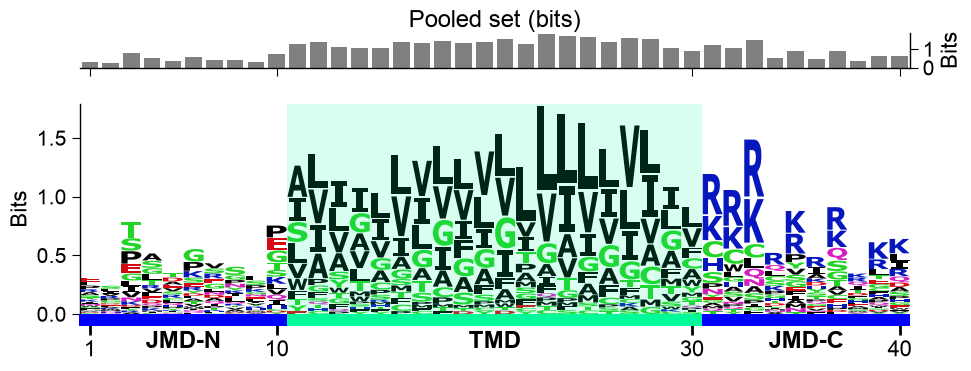

In [5]:
# Same pooled set, letters scaled to information content (bits) instead of probability.
aal = aa.AALogo(logo_type="information")
df_logo_bits = aal.get_df_logo(df_parts=df_parts, labels=None, label_test=1, tmd_len=20, start_n=True,
                               characters_to_ignore=".-", pseudocount=0.0)

aal_plot = aa.AALogoPlot(logo_type="information", jmd_n_len=10, jmd_c_len=10, verbose=False)
fig, ax = aal_plot.single_logo(
    # data: a precomputed logo, so the on-the-fly inputs (aal_kws, df_parts, labels, ...) stay unset
    df_logo=df_logo_bits, df_logo_info=df_logo_info, aal_kws=None,
    df_parts=None, labels=None, label_test=1, tmd_len=None,
    # conservation bar on top (same bits as the stack heights below it)
    info_bar_color="gray", info_bar_ylim=None, height_ratio=(1, 6),
    # figure, axis and dataset annotation
    target_p1_site=None, figsize=(10, 4), fontsize_labels=None,
    name_data="Pooled set (bits)", name_data_pos="top", name_data_color="black", name_data_fontsize=None,
    # letters
    logo_font_name="Verdana", logo_color_scheme="weblogo_protein", logo_stack_order="big_on_top",
    logo_width=0.96, logo_vpad=0.05, logo_vsep=0.0,
    # part annotation along the x-axis
    start=1, tmd_color="mediumspringgreen", jmd_color="blue",
    fontsize_tmd_jmd=aa.plot_gcfs() + 1, weight_tmd_jmd="bold",
    highlight_tmd_area=True, highlight_alpha=0.15,
    xtick_size=None, xtick_width=2.0, xtick_length=11.0,
)
plt.tight_layout()
plt.show()

**Signal vs chance: the shuffled baseline.** Bits never drop to zero on a finite set: with 50 sequences, residues pile up at some positions by chance alone. So a gray bar is only informative next to a baseline. The simplest honest baseline keeps every sequence's residues and part lengths but shuffles their order, which preserves composition and destroys position. Profile both and compare, region by region.

In [6]:
rng = np.random.default_rng(42)


def shuffle_parts(df_parts, rng):
    """Shuffle residues within each sequence across jmd_n + tmd + jmd_c, keeping part lengths."""
    rows = []
    for jmd_n, tmd, jmd_c in df_parts[["jmd_n", "tmd", "jmd_c"]].itertuples(index=False):
        seq = "".join(rng.permutation(list(jmd_n + tmd + jmd_c)))
        n, t = len(jmd_n), len(tmd)
        rows.append({"jmd_n": seq[:n], "tmd": seq[n:n + t], "jmd_c": seq[n + t:]})
    return pd.DataFrame(rows, index=df_parts.index)


aal = aa.AALogo(logo_type="probability")
df_parts_shuffled = shuffle_parts(df_parts, rng)
df_logo_info_shuffled = aal.get_df_logo_info(df_parts=df_parts_shuffled, tmd_len=20)

# Conservation per region (positions 1-10 jmd_n, 11-30 tmd, 31-40 jmd_c), real vs shuffled.
regions = {"jmd_n": slice(0, 10), "tmd": slice(10, 30), "jmd_c": slice(30, 40)}
rows = []
for name_set, info in [("real", df_logo_info), ("shuffled", df_logo_info_shuffled)]:
    for region, positions in regions.items():
        row = {"set": name_set, "region": region}
        for value_type in ["min", "mean", "median", "max"]:
            row[value_type] = aal.get_conservation(df_logo_info=info.iloc[positions], value_type=value_type)
        rows.append(row)
df_cons_region = pd.DataFrame(rows).round(2)
aa.display_df(df=df_cons_region, n_rows=10, show_shape=True)

DataFrame shape: (6, 6)


,set,region,min,mean,median,max
1,real,jmd_n,0.240000,0.470000,0.420000,0.790000
2,real,tmd,0.920000,1.370000,1.370000,1.790000
3,real,jmd_c,0.350000,0.820000,0.760000,1.500000
4,shuffled,jmd_n,0.460000,0.630000,0.640000,0.780000
5,shuffled,tmd,0.330000,0.620000,0.670000,0.970000
6,shuffled,jmd_c,0.590000,0.720000,0.730000,0.840000


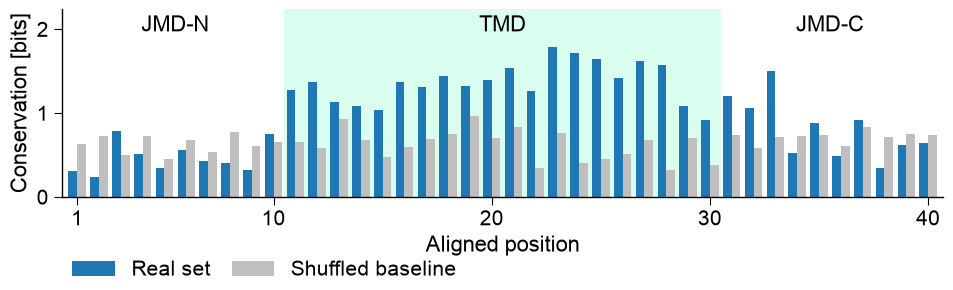

In [7]:
c_real = aa.plot_get_clist(n_colors=3)[1]
x = np.arange(1, len(df_logo_info) + 1)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.axvspan(10.5, 30.5, color="mediumspringgreen", alpha=0.15, lw=0)   # the aligned TMD
ax.bar(x - 0.2, df_logo_info.values, width=0.4, color=c_real)
ax.bar(x + 0.2, df_logo_info_shuffled.values, width=0.4, color="0.75")
y_max = 1.25 * max(df_logo_info.max(), df_logo_info_shuffled.max())
for region, (lo, hi) in {"JMD-N": (1, 10), "TMD": (11, 30), "JMD-C": (31, 40)}.items():
    ax.text((lo + hi) / 2, y_max * 0.97, region, ha="center", va="top", size=aa.plot_gcfs())
ax.set_ylim(0, y_max)
ax.set_xlim(0.3, len(x) + 0.7)
ax.set_xticks([1, 10, 20, 30, 40])
ax.set_xlabel("Aligned position")
ax.set_ylabel("Conservation [bits]")
ax.spines[["top", "right"]].set_visible(False)
aa.plot_legend(ax=ax, dict_color={"Real set": c_real, "Shuffled baseline": "0.75"},
               loc="upper left", loc_out=True, y=-0.28, x=0, n_cols=2, fontsize=aa.plot_gcfs() - 1)
plt.tight_layout()
plt.show()

Read the colored bars against the gray ones. Over the TMD the real set sits clearly above its shuffled twin: that is positional signal. Over JMD-N the real set sits at or even below the baseline (the shuffle pours the TMD's strongly hydrophobic residues into the flank, which makes the shuffled flank look *more* conserved than the real one), so the JMD-N bars in the first logo are what chance alone produces at this set size. JMD-C is near the baseline too, except for its first few positions: the basic R/K residues right after the TMD, visible as tall blue letters in the logos, are a genuine positional feature.

**Comparing two groups.** The pooled logo above *describes* one set; it does **not** *compare* groups. To contrast two groups you draw fixed-length **windows** per group with `AAWindowSampler`, then profile each. Below, `sample_same_protein` draws TMD-centred windows from the **substrate** proteins (Same-protein, the ones carrying a positive site) and `sample_different_protein` draws matched windows from the **non-substrate** proteins (Different-protein, none). Pooling each strategy's equal-length windows into one aligned block and stacking the two logos with `AALogoPlot.multi_logo` lines them up position by position, so composition differences read straight off the figure. This side-by-side is the protocol's gallery thumbnail, and a preview of **P3: Sampling**.

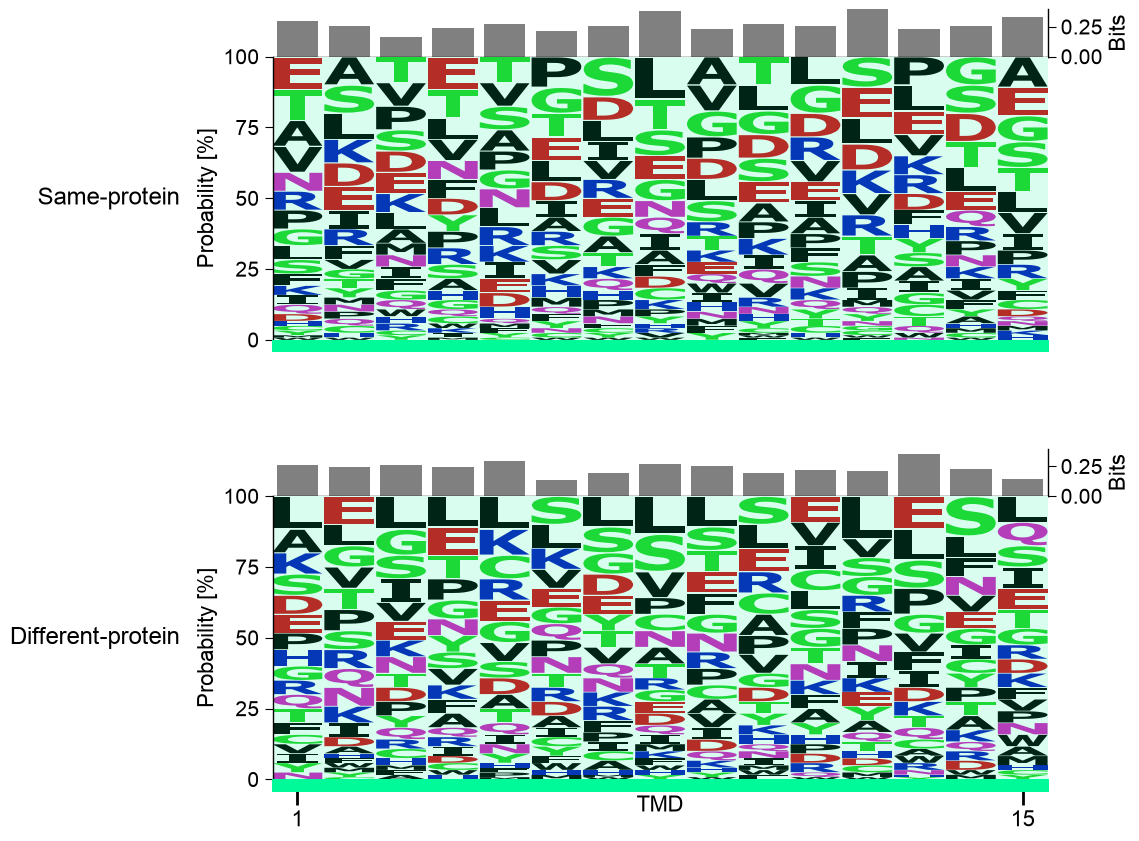

In [8]:
import pandas as pd

# Reproducibility knobs shared with this protocol's gallery thumbnail so both match.
WINDOW_SIZE, N_WINDOWS, SEED = 15, 120, 42

# Mark each substrate's TMD centre as a positive site; leave the non-substrates unlabeled.
# sample_same_protein then draws from proteins that carry a positive site, while
# sample_different_protein draws matched windows from proteins with none.
df_seq_pos = df_seq.copy()
centre = ((df_seq_pos["tmd_start"] + df_seq_pos["tmd_stop"]) // 2).astype(int)
df_seq_pos["pos"] = [[int(c)] if lbl == 1 else [] for c, lbl in zip(centre, df_seq_pos["label"])]

# Every sampler option by name. The similarity filters stay off here (P3 is where they earn their keep).
aaws = aa.AAWindowSampler(
    verbose=False, random_state=SEED,
    max_similarity_to_test=None,      # a value in (0, 1] would drop windows too similar to a test window
    max_similarity_within_ref=None,   # and windows too similar to an already kept reference window
    filter_iteratively=True, max_sampling_attempts=10,
    custom_filter=None,               # optional keep-predicate (window, entry, source_position) -> bool
)
df_same = aaws.sample_same_protein(
    df_seq=df_seq_pos, n=N_WINDOWS, window_size=WINDOW_SIZE, pos_col="pos",
    min_distance_to_pos=None, max_distance_to_pos=None,   # no distance band, so every fitting window is admissible
    label_test=1, label_ref=0, role="Negative", output_mode="segments",
    aa_context_col=None, context_in=None, context_out=None,   # per-residue context tags (unused here)
    motif_pwm=None, motif_score_threshold=None, motif_match="in",   # PWM filter (unused here, see P3)
    seed=SEED,
)
df_diff = aaws.sample_different_protein(
    df_seq=df_seq_pos, n=N_WINDOWS, window_size=WINDOW_SIZE, pos_col="pos",
    candidate_proteins=None,          # None: every protein without a positive; or a list of entries
    label_test=1, label_ref=0, role="Unlabeled", output_mode="segments",
    aa_context_col=None, context_in=None, context_out=None,
    motif_pwm=None, motif_score_threshold=None, motif_match="in",
    seed=SEED,
)

# Each strategy's windows are equal-length segments, so pool them into one aligned
# block and profile with AALogo (reusing aal, the probability logo from above).
list_df_logo, list_df_logo_info = [], []
for df_group in (df_same, df_diff):
    df_win = pd.DataFrame({"tmd": df_group["window"].to_list()})
    list_df_logo.append(aal.get_df_logo(df_parts=df_win, tmd_len=WINDOW_SIZE))
    list_df_logo_info.append(aal.get_df_logo_info(df_parts=df_win, tmd_len=WINDOW_SIZE))

# jmd_n_len = jmd_c_len = 0: each pooled window is one aligned block (no JMD flanks).
aal_plot = aa.AALogoPlot(logo_type="probability", jmd_n_len=0, jmd_c_len=0, verbose=False)
fig, ax = aal_plot.multi_logo(
    list_df_logo=list_df_logo,
    list_df_logo_info=list_df_logo_info,
    list_name_data=["Same-protein", "Different-protein"],
    name_data_pos="left",
    figsize_per_logo=(10, 5),
)
plt.tight_layout()
plt.show()

A caution before reading that figure as *substrate vs non-substrate*: the Same-protein windows are centred on each substrate's TMD, while the Different-protein windows can start anywhere along the non-substrates. Part of the difference is therefore *where* the windows sit, not *which* group they come from, which is exactly the kind of sampling choice P3 is about.

The like-for-like group contrast stays on the same parts and changes only the grouping: pass the `label` column as `labels` and pick the group with `label_test`. Same positions, same alignment, one logo per group. The call lists every `multi_logo` parameter by name.

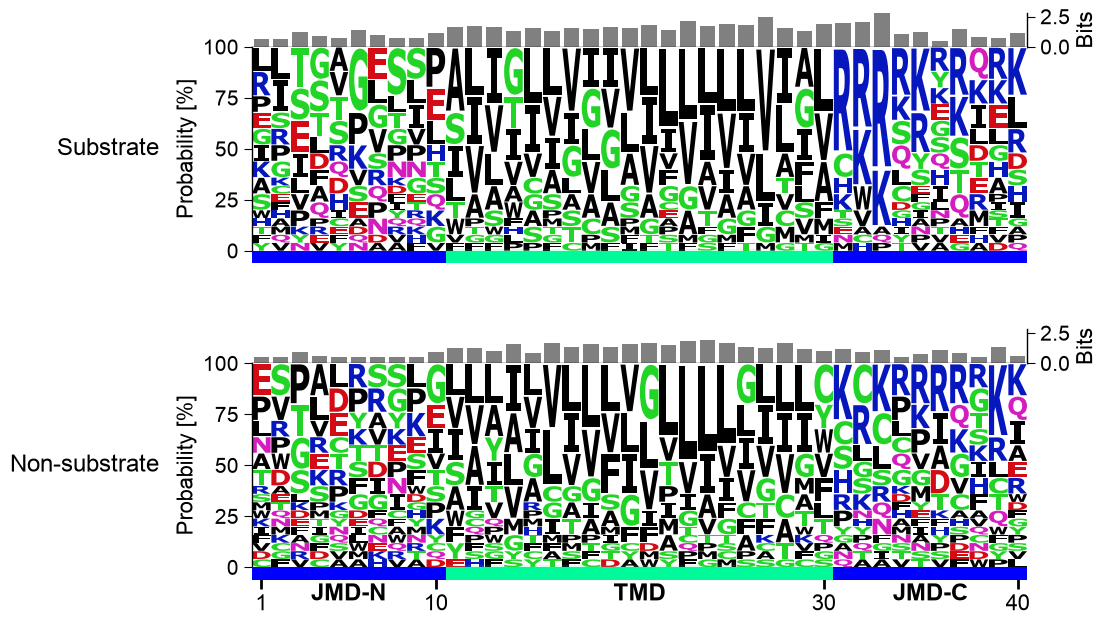

In [9]:
labels = df_seq["label"].to_list()   # 1 = substrate, 0 = non-substrate (now we do use it)
aal = aa.AALogo(logo_type="probability")
list_df_logo_groups, list_df_logo_info_groups = [], []
for label_test in (1, 0):
    list_df_logo_groups.append(aal.get_df_logo(
        df_parts=df_parts, labels=labels, label_test=label_test, tmd_len=20, start_n=True,
        characters_to_ignore=".-", pseudocount=0.0))
    list_df_logo_info_groups.append(aal.get_df_logo_info(
        df_parts=df_parts, labels=labels, label_test=label_test, tmd_len=20, start_n=True,
        characters_to_ignore=".-", pseudocount=0.0))

aal_plot = aa.AALogoPlot(logo_type="probability", jmd_n_len=10, jmd_c_len=10, verbose=False)
fig, axes = aal_plot.multi_logo(
    # data: one precomputed logo (+ bits) per group, so list_aal_kws stays unset
    list_df_logo=list_df_logo_groups, list_df_logo_info=list_df_logo_info_groups, list_aal_kws=None,
    # conservation bars share one y-range, so group heights are comparable
    info_bar_color="gray", info_bar_ylim=None, height_ratio=(1, 6),
    # layout and group names
    target_p1_site=None, figsize_per_logo=(10, 3.6), fontsize_labels=None,
    list_name_data=["Substrate", "Non-substrate"], name_data_pos="left",
    list_name_data_color="black", name_data_fontsize=None,
    # letters
    logo_font_name="Verdana", logo_color_scheme="weblogo_protein", logo_stack_order="big_on_top",
    logo_width=0.96, logo_vpad=0.05, logo_vsep=0.0,
    # part annotation along the x-axis
    start=1, tmd_color="mediumspringgreen", jmd_color="blue",
    fontsize_tmd_jmd=aa.plot_gcfs() + 1, weight_tmd_jmd="bold",
    highlight_tmd_area=True, highlight_alpha=0.15,
    xtick_size=None, xtick_width=2.0, xtick_length=11.0,
)
plt.tight_layout()
plt.show()

In [10]:
# The same comparison as numbers: mean bits per region, per group.
df_cons_groups = pd.DataFrame(
    {region: [aal.get_conservation(df_logo_info=info.iloc[positions], value_type="mean")
              for info in list_df_logo_info_groups]
     for region, positions in regions.items()},
    index=["Substrate (25)", "Non-substrate (25)"],
).round(2)
aa.display_df(df=df_cons_groups, n_rows=10, show_shape=True)

DataFrame shape: (2, 3)


,jmd_n,tmd,jmd_c
Substrate (25),0.900000,1.690000,1.380000
Non-substrate (25),0.620000,1.440000,0.900000


Now two groups share one set of positions, and differences in letters or bars can be attributed to the grouping. Keep two things in mind. Each group has only 25 sequences, so its bits sit on a higher chance floor than the pooled 50 (see the last common mistake below). And a logo still only shows *composition*: which physicochemical property separates the groups, and where, is the question **CPP** answers (P1: CPP signature).

**How to interpret.** A few things happened here. The colored letters trace **what** sits at each position: where the stack collapses onto one or two tall letters, that position is compositionally dominated. The gray bars trace **how conserved** each position is, and the shuffled baseline tells you how much of that height is signal: in this set the TMD rises well above its shuffled twin (mean 1.37 vs 0.62 bits), JMD-N stays at the baseline and JMD-C rises above it only at the basic R/K positions next to the TMD, so positional signal concentrates in and right after the TMD.

| Region | High bits there (above the shuffled baseline) means ... |
|---|---|
| `jmd_n` / `jmd_c` (flanks) | the juxtamembrane context is constrained, not just variable linker |
| `tmd` (core) | the membrane span carries a conserved positional pattern, a candidate place to look once you have labels |

| Figure | What it isolates | Contrast |
|---|---|---|
| probability logo | composition per position | (reference view) |
| information logo | conservation per position | same set, letters scaled to bits |
| real vs shuffled bars | signal vs chance | same residues, order destroyed |
| window logos | a first two-group look | windows drawn by two sampling strategies |
| substrate vs non-substrate logos | the grouping itself | same parts, split by `label` |

**Key takeaways**

- A logo reads **composition**; information content (bits) reads **conservation**: two different questions, which the probability and information views separate.
- Bits are only meaningful against a **baseline**: a shuffled copy of the same residues shows how much conservation chance alone produces at your set size.
- Pooling every sequence is **determinant-free**: it *describes* one set. Splitting the same parts by `label` gives a like-for-like group contrast, a preview of what **CPP** then turns into a **signature**.

**Common mistakes.**

- **Feeding the default parts to the logo plot.** `SequenceFeature.get_df_parts` defaults to `tmd` / `jmd_n_tmd_n` / `tmd_c_jmd_c`; `AALogo` then sees only the `tmd` column and you get a TMD-only logo. Pairing that with `AALogoPlot(jmd_n_len=10, jmd_c_len=10)` raises a length error (the JMD lengths no longer fit the logo). Always request `list_parts=["jmd_n", "tmd", "jmd_c"]`.
- **Keeping the JMD lengths out of sync.** `AALogoPlot(jmd_n_len, jmd_c_len)` must match the `jmd_n_len` / `jmd_c_len` you passed to `get_df_parts`.
- **Reading a logo as a discriminative result.** High conservation across the pooled set says *nothing* about test vs reference, that needs **CPP**. The logo is a one-set description, not a contrast.
- **Reading bits from a handful of sequences.** With few sequences even shuffled residues look conserved, so a tall bar can be pure chance. Check against a shuffled baseline, and prefer dozens of sequences.
- **Wrong unit for residue-level data.** For windowed / per-residue tasks (`AA_*`) you would first sample fixed-length **windows** with `AAWindowSampler`, then profile those: same *look-before-you-label* idea, different **unit of comparison** (a window instead of a part set).

The first and fourth mistakes are quick to see for yourself.

In [11]:
# Mistake 1: default parts -> the logo has only the 20 aligned TMD positions, so 10 + 10 JMD positions cannot fit.
df_parts_default = sf.get_df_parts(df_seq=df_seq)           # tmd / jmd_n_tmd_n / tmd_c_jmd_c
aal = aa.AALogo(logo_type="probability")
df_logo_default = aal.get_df_logo(df_parts=df_parts_default, tmd_len=20)
aal_plot = aa.AALogoPlot(logo_type="probability", jmd_n_len=10, jmd_c_len=10, verbose=False)
try:
    aal_plot.single_logo(df_logo=df_logo_default)
    message = "no error"
except ValueError as err:
    message = str(err)
    plt.close("all")
df_mistake = pd.DataFrame({"parts": [", ".join(df_parts_default.columns)],
                           "logo positions": [len(df_logo_default)],
                           "ValueError": [message]})
aa.display_df(df=df_mistake, n_rows=10, show_shape=True, char_limit=100)

DataFrame shape: (1, 3)


,parts,logo positions,ValueError
1,"tmd, jmd_n_tmd_n, tmd_c_jmd_c",20,'jmd_n_len' (10) + 'jmd_c_len' (10) must be < logo length from 'df_logo' (20).


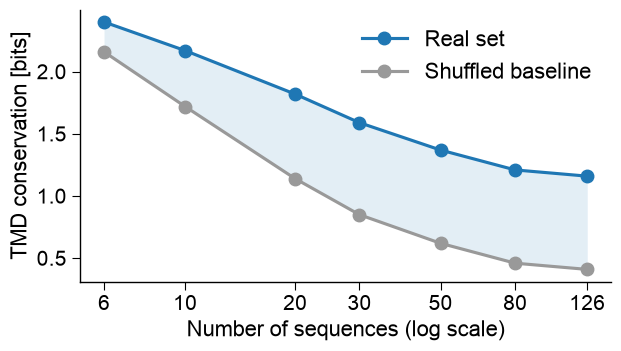

In [12]:
# Mistake 4: the chance floor. Mean TMD bits for the real set vs its shuffled twin, by set size.
list_n = [3, 5, 10, 15, 25, 40, 63]          # per class; 63 is the full DOM_GSEC set
rows = []
for n in list_n:
    df_parts_n = sf.get_df_parts(df_seq=aa.load_dataset(name="DOM_GSEC", n=n),
                                 list_parts=["jmd_n", "tmd", "jmd_c"], jmd_n_len=10, jmd_c_len=10)
    info_real = aal.get_df_logo_info(df_parts=df_parts_n, tmd_len=20)
    info_shuffled = aal.get_df_logo_info(df_parts=shuffle_parts(df_parts_n, np.random.default_rng(42)), tmd_len=20)
    rows.append({"n_sequences": len(df_parts_n),
                 "real TMD": aal.get_conservation(df_logo_info=info_real.iloc[10:30], value_type="mean"),
                 "shuffled TMD": aal.get_conservation(df_logo_info=info_shuffled.iloc[10:30], value_type="mean")})
df_floor = pd.DataFrame(rows).round(2)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(df_floor["n_sequences"], df_floor["real TMD"], marker="o", color=c_real, label="Real set")
ax.plot(df_floor["n_sequences"], df_floor["shuffled TMD"], marker="o", color="0.6", label="Shuffled baseline")
ax.fill_between(df_floor["n_sequences"], df_floor["shuffled TMD"], df_floor["real TMD"], color=c_real, alpha=0.12, lw=0)
ax.set_xscale("log")
ax.set_xticks(df_floor["n_sequences"])
ax.set_xticklabels(df_floor["n_sequences"])
ax.minorticks_off()
ax.set_xlabel("Number of sequences (log scale)")
ax.set_ylabel("TMD conservation [bits]")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

With six sequences the shuffled baseline is almost as tall as the real set: the logo would look conserved even if position carried no information. The gap (shaded) only opens up with a few dozen sequences, and it is that gap, not the raw bar height, that you can read as positional signal.

**Next step.** Continue with **P3: Sampling** to draw the balanced, fixed-length sequence sets you will need once you attach labels and run a comparison.